In [1]:
from pathlib import Path
import datajoint as dj

dj.config.load(
    Path("dj_local_conf.json").absolute()
)  # replace with your config file name

/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-10-03 14:41:36,440][INFO]: DataJoint is configured from /home/sgao/source/sgao_analysis/dj_local_conf.json


In [2]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
SortedSpikesGroup()

[2026-10-03 14:41:39,073][INFO]: DataJoint 0.14.5 connected to sgao@lmf-db.cin.ucsf.edu:3306


nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Bilbo20230724_.nwb,default_exclusion,04_lineartrack
Bilbo20230724_.nwb,default_exclusion,06_lineartrack
Bilbo20230724_.nwb,default_exclusion,08_lineartrack
Bilbo20230724_.nwb,default_exclusion,10_lineartrack
Bilbo20230724_.nwb,default_exclusion,12_lineartrack
Bilbo20230725_.nwb,default_exclusion,02_lineartrack
Bilbo20230725_.nwb,default_exclusion,04_lineartrack
Bilbo20230725_.nwb,default_exclusion,06_lineartrack
Bilbo20230725_.nwb,default_exclusion,08_lineartrack
Bilbo20230725_.nwb,default_exclusion,10_lineartrack


In [20]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

(SortedSpikesGroup & 'nwb_file_name LIKE "embry%"').fetch("nwb_file_name")

array(['Embry20260604_.nwb', 'Embry20260604_.nwb'], dtype=object)

In [4]:
SortedSpikesGroup & {"nwb_file_name": "Embry20260604_.nwb"}

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Embry20260604_.nwb,exclude_all_other,mPFC_opto
Embry20260604_.nwb,exclude_all_other,mPFC_test_shank6


In [5]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

nwb_file_name = "Embry20260604_.nwb"

group_key = {
    "nwb_file_name": nwb_file_name,
    "sorted_spikes_group_name":"mPFC_opto",
}
SortedSpikesGroup & group_key

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Embry20260604_.nwb,exclude_all_other,mPFC_opto


In [6]:
# here we can see that I put 4 sort groups (4 shanks in the mPFC) into this one sorted spikes group
SortedSpikesGroup.Units & group_key

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name,spikesorting_merge_id
Embry20260604_.nwb,exclude_all_other,mPFC_opto,8c13ce25-4d5e-4677-70ec-cf9b48ce4517
Embry20260604_.nwb,exclude_all_other,mPFC_opto,b303a15c-b266-6c96-306e-a8726bd06a64
Embry20260604_.nwb,exclude_all_other,mPFC_opto,b3ae0686-a46f-0815-a07d-8ac8bce6de94
Embry20260604_.nwb,exclude_all_other,mPFC_opto,be821e8d-c7bc-9642-08df-8e58ba507024


In [7]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
group_key ={'nwb_file_name': 'Embry20260604_.nwb',
 'sorted_spikes_group_name': 'mPFC_opto'}

In [8]:
# get the complete key
group_key = (SortedSpikesGroup & group_key).fetch1("KEY")
# get the spike data, returns a list of unit spike times
SortedSpikesGroup().fetch_spike_data(group_key)

[14:43:53][WARNING] Spyglass: Missing code for CurationV2
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/MarketTech LuxX+ Red/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 1/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 2/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/

[array([1.78059561e+09, 1.78059561e+09, 1.78059561e+09, ...,
        1.78061722e+09, 1.78061722e+09, 1.78061722e+09]),
 array([1.78059561e+09, 1.78059561e+09, 1.78059561e+09, ...,
        1.78061722e+09, 1.78061722e+09, 1.78061722e+09]),
 array([1.78059561e+09, 1.78059561e+09, 1.78059561e+09, ...,
        1.78061722e+09, 1.78061722e+09, 1.78061722e+09]),
 array([1.78059561e+09, 1.78059561e+09, 1.78059561e+09, ...,
        1.78061722e+09, 1.78061722e+09, 1.78061722e+09]),
 array([1.78059564e+09, 1.78059569e+09, 1.78059572e+09, 1.78059572e+09,
        1.78059575e+09, 1.78059576e+09, 1.78059576e+09, 1.78059576e+09,
        1.78059580e+09, 1.78059582e+09, 1.78059584e+09, 1.78059586e+09,
        1.78059587e+09, 1.78059587e+09, 1.78059590e+09, 1.78059591e+09,
        1.78059597e+09, 1.78059597e+09, 1.78059597e+09, 1.78059598e+09,
        1.78059599e+09, 1.78059599e+09, 1.78059605e+09, 1.78059605e+09,
        1.78059608e+09, 1.78059609e+09, 1.78059609e+09, 1.78059610e+09,
        1.78059613e+

In [9]:
import pynwb

pynwb.__version__

'3.1.3'

In [10]:
spike_times, unit_ids = SortedSpikesGroup().fetch_spike_data(
    group_key, return_unit_ids=True
)

[14:45:27][WARNING] Spyglass: Missing code for CurationV2


In [11]:
import numpy as np
import pynwb
import spyglass.common as sgc

#this reads the raw nwb file so we can get laser DIO times
io = pynwb.NWBHDF5IO("/stelmo/nwb/raw/Embry20260604.nwb", mode="r")
nwbf = io.read()

In [12]:
epoch_number = 0 # this goes from 0-9 and we can reference the google sheet to figure what laser power it is

epoch_start_time, epoch_stop_time, epoch_name = nwbf.intervals['epochs'][epoch_number].to_numpy()[0]

laser_data = nwbf.processing['behavior'].data_interfaces['behavioral_events'].time_series['Laser'].data[:]
laser_timestamps = nwbf.processing['behavior'].data_interfaces['behavioral_events'].time_series['Laser'].timestamps[:]

# Restrict to epoch
mask = (laser_timestamps > epoch_start_time) & (laser_timestamps <= epoch_stop_time)

laser_data_epoch = laser_data[mask]
laser_timestamps_epoch = laser_timestamps[mask]

# Ensure clean start
laser_data_epoch[0] = 0

# --- KEY STEP: only look at ON samples ---
laser_on_times_epoch = laser_timestamps_epoch[laser_data_epoch == 1]

# --- Detect first pulse of each train ---
first_laser_on_times = laser_on_times_epoch[
    np.insert(np.diff(laser_on_times_epoch) > 0.01, 0, True)
]

In [14]:
unit = spike_times[1]
laser = first_laser_on_times[0]

window_spikes = unit[(unit > laser - 0.2) & (unit < laser + 0.2)]
print(window_spikes - laser)

[-0.14510274  0.06443453]


laser 0

In [15]:
mi_list = []

for unit in spike_times:

    pre_counts = []
    post_counts = []

    for laser in first_laser_on_times:
        pre = np.sum((unit >= laser - 0.2) & (unit < laser))
        post = np.sum((unit >= laser) & (unit < laser + 0.2))

        pre_counts.append(pre)
        post_counts.append(post)

    pre_avg = np.mean(pre_counts)
    post_avg = np.mean(post_counts)

    mi = (post_avg - pre_avg) / (post_avg + pre_avg + 1e-9)

    mi_list.append(mi)

mean_mi = np.mean(mi_list)

print("Number of neurons:", len(mi_list))
print("Mean MI:", mean_mi)

Number of neurons: 92
Mean MI: 0.1668216188486111


entire session

In [17]:
len(nwbf.intervals['epochs'])

11

In [19]:
epoch_mi = []

for epoch_number in range(len(nwbf.intervals['epochs'])):

    epoch_start_time, epoch_stop_time, epoch_name = (
        nwbf.intervals['epochs'][epoch_number].to_numpy()[0]
    )

    mask = (
        (laser_timestamps > epoch_start_time)
        & (laser_timestamps <= epoch_stop_time)
    )

    laser_data_epoch = laser_data[mask].copy()
    laser_timestamps_epoch = laser_timestamps[mask]

    # No laser data at all in this epoch
    if len(laser_data_epoch) == 0:
        print(f"Epoch {epoch_number} ({epoch_name}): no laser data")
        epoch_mi.append(np.nan)
        continue

    laser_data_epoch[0] = 0

    laser_on_times_epoch = laser_timestamps_epoch[
        laser_data_epoch == 1
    ]

    # Laser data exists, but laser never turns on
    if len(laser_on_times_epoch) == 0:
        print(f"Epoch {epoch_number} ({epoch_name}): no laser ON events")
        epoch_mi.append(np.nan)
        continue

    first_laser_on_times = laser_on_times_epoch[
        np.insert(
            np.diff(laser_on_times_epoch) > 0.01,
            0,
            True
        )
    ]

    mi_list = []

    for unit in spike_times:

        pre_counts = []
        post_counts = []

        for laser in first_laser_on_times:
            pre = np.sum((unit >= laser - 0.2) & (unit < laser))
            post = np.sum((unit >= laser) & (unit < laser + 0.2))

            pre_counts.append(pre)
            post_counts.append(post)

        pre_avg = np.mean(pre_counts)
        post_avg = np.mean(post_counts)

        mi = (post_avg - pre_avg) / (
            post_avg + pre_avg + 1e-9
        )

        mi_list.append(mi)

    epoch_mi.append(np.mean(mi_list))

Epoch 1 (['02_r1']): no laser ON events
Epoch 3 (['04_r2']): no laser ON events
Epoch 5 (['06_r3']): no laser ON events
Epoch 7 (['08_r4']): no laser ON events
Epoch 9 (['10_r5']): no laser ON events


In [23]:
for epoch_number in range(len(nwbf.intervals['epochs'])):

    epoch_start_time, epoch_stop_time, epoch_name = (
        nwbf.intervals['epochs'][epoch_number].to_numpy()[0]
    )

    mask = (
        (laser_timestamps > epoch_start_time)
        & (laser_timestamps <= epoch_stop_time)
    )

    laser_data_epoch = laser_data[mask]

    print(
        f"Epoch {epoch_number}:",
        epoch_name,
        "| laser samples:",
        np.sum(laser_data_epoch == 1)
    )

Epoch 0: ['01_s1'] | laser samples: 40
Epoch 1: ['02_r1'] | laser samples: 0
Epoch 2: ['03_s2'] | laser samples: 54640
Epoch 3: ['04_r2'] | laser samples: 0
Epoch 4: ['05_s3'] | laser samples: 49780
Epoch 5: ['06_r3'] | laser samples: 0
Epoch 6: ['07_s4'] | laser samples: 44960
Epoch 7: ['08_r4'] | laser samples: 0
Epoch 8: ['09_s5'] | laser samples: 58400
Epoch 9: ['10_r5'] | laser samples: 0
Epoch 10: ['11_s6'] | laser samples: 48400


In [24]:
import numpy as np

stim_epochs = [0, 2, 4, 6, 8, 10]

marcus_mi = np.array(epoch_mi)[stim_epochs]

print(marcus_mi)

[ 0.16682162  0.05541536  0.05421165 -0.00947364  0.03928012  0.04254866]


In [25]:
for epoch_number in [0, 2, 4, 6, 8, 10]:

    epoch_start_time, epoch_stop_time, epoch_name = (
        nwbf.intervals['epochs'][epoch_number].to_numpy()[0]
    )

    mask = (
        (laser_timestamps > epoch_start_time)
        & (laser_timestamps <= epoch_stop_time)
    )

    laser_data_epoch = laser_data[mask].copy()
    laser_timestamps_epoch = laser_timestamps[mask]

    laser_on_times_epoch = laser_timestamps_epoch[
        laser_data_epoch == 1
    ]

    if len(laser_on_times_epoch) > 0:
        first_laser_on_times = laser_on_times_epoch[
            np.insert(
                np.diff(laser_on_times_epoch) > 0.01,
                0,
                True
            )
        ]

        print(
            epoch_name,
            "laser events:",
            len(first_laser_on_times)
        )

['01_s1'] laser events: 2
['03_s2'] laser events: 2732
['05_s3'] laser events: 2489
['07_s4'] laser events: 2248
['09_s5'] laser events: 2920
['11_s6'] laser events: 2420


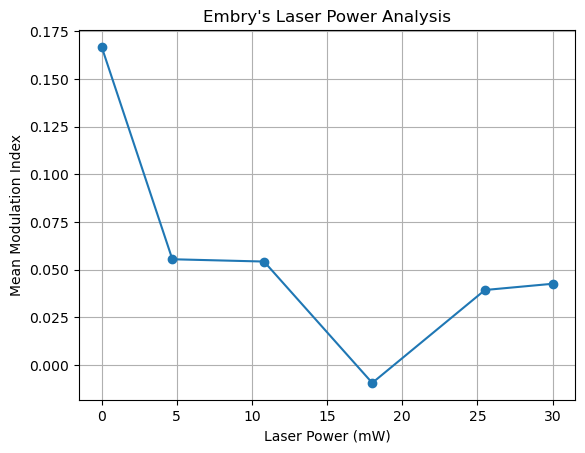

In [28]:
import matplotlib.pyplot as plt
import numpy as np

stim_epochs = [0, 2, 4, 6, 8, 10]
marcus_mi = np.array(epoch_mi)[stim_epochs]

laser_power = [0, 4.7, 10.8, 18, 25.5, 30]  # replace if needed

plt.plot(laser_power, marcus_mi, marker='o')

plt.xlabel("Laser Power (mW)")
plt.ylabel("Mean Modulation Index")
plt.title("Embry's Laser Power Analysis")

plt.grid(True)
plt.show()